  t-SNE NON-LINEAR MANIFOLD EMBEDDING FROM SCRATCH
Input Data Matrix Shape     : (150, 64) (64 Features)
Iteration [100/300] - KL Loss: 0.058007
Iteration [200/300] - KL Loss: 0.058007
Iteration [300/300] - KL Loss: 0.058007
Completed t-SNE Projection Successfully!


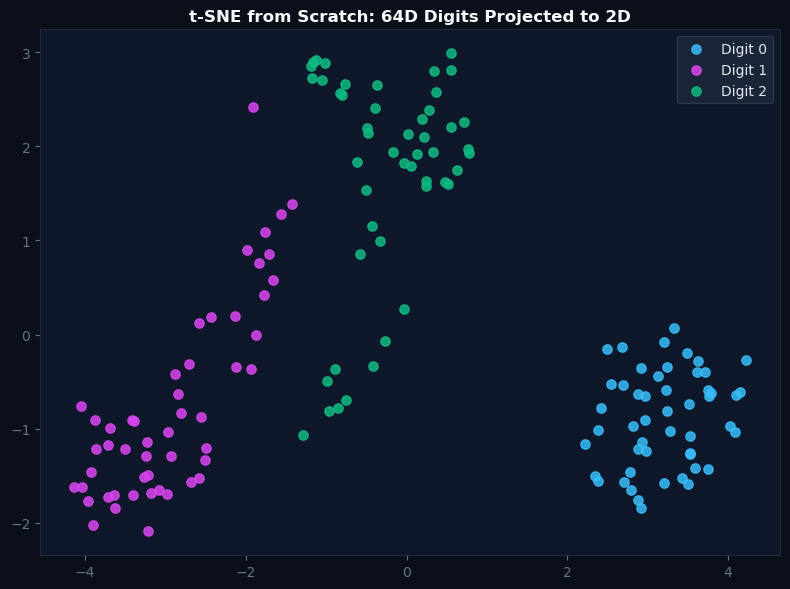

Saved embedding plot to tsne_scratch_demo.png


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits


class TSNEFromScratch:
  """t-Distributed Stochastic Neighbor Embedding (t-SNE) implemented in pure NumPy."""

  def __init__(
      self,
      n_components=2,
      perplexity=30.0,
      n_iter=500,
      lr=200.0,
      momentum=0.8,
  ):
    self.n_components = n_components
    self.perplexity = perplexity
    self.n_iter = n_iter
    self.lr = lr
    self.momentum = momentum

  def _compute_pairwise_affinities(self, X):
    """Computes symmetrized high-dimensional affinities p_ij."""
    n_samples = X.shape[0]
    # Compute Euclidean distance squared
    sum_X = np.sum(np.square(X), axis=1)
    D = np.add(np.add(-2 * np.dot(X, X.T), sum_X).T, sum_X)
    np.fill_diagonal(D, 0.0)

    # Simplified fixed-bandwidth Gaussian kernel (scaled to perplexity estimate)
    # sigma^2 calibrated via median distance heuristic
    sigma2 = np.median(D[D > 0]) / (2.0 * np.log(self.perplexity))
    P = np.exp(-D / (2.0 * sigma2))
    np.fill_diagonal(P, 0.0)

    # Normalize conditional probabilities
    P_cond = P / (np.sum(P, axis=1, keepdims=True) + 1e-12)

    # Symmetrize: p_ij = (p_j|i + p_i|j) / (2N)
    P_sym = (P_cond + P_cond.T) / (2.0 * n_samples)
    return np.maximum(P_sym, 1e-12)

  def fit_transform(self, X):
    n_samples = X.shape[0]

    # 1. Compute High-Dimensional Probabilities P
    P = self._compute_pairwise_affinities(X)

    # 2. Initialize Low-Dimensional Coordinates randomly (Gaussian with small variance)
    np.random.seed(42)
    Y = np.random.normal(0.0, 1e-4, (n_samples, self.n_components))
    Y_prev = np.copy(Y)

    # 3. Gradient Descent Loop
    for it in range(self.n_iter):
      # Compute low-dimensional Student-t affinities q_ij
      sum_Y = np.sum(np.square(Y), axis=1)
      dist_Y = np.add(np.add(-2 * np.dot(Y, Y.T), sum_Y).T, sum_Y)

      # 1-DOF Student-t kernel: (1 + ||y_i - y_j||^2)^(-1)
      num = 1.0 / (1.0 + dist_Y)
      np.fill_diagonal(num, 0.0)
      Q = num / np.sum(num)
      Q = np.maximum(Q, 1e-12)

      # Compute Gradient dC/dy_i
      # grad shape: (n_samples, n_components)
      PQ_diff = P - Q
      grad = np.zeros((n_samples, self.n_components))
      for i in range(n_samples):
        # 4 * sum_j (p_ij - q_ij) * (y_i - y_j) * (1 + ||y_i - y_j||^2)^(-1)
        grad[i] = 4.0 * np.sum(
            (PQ_diff[:, i] * num[:, i])[:, np.newaxis] * (Y[i] - Y), axis=0
        )

      # Update coordinates with momentum
      step = self.lr * grad
      Y_new = Y - step + self.momentum * (Y - Y_prev)

      Y_prev = np.copy(Y)
      Y = Y_new

      # Zero-center embedding to prevent coordinates from drifting
      Y -= np.mean(Y, axis=0)

      if (it + 1) % 100 == 0:
        kl_loss = np.sum(P * np.log(P / Q))
        print(f"Iteration [{it+1:3d}/{self.n_iter}] - KL Loss: {kl_loss:.6f}")

    return Y


# =========================================================================
# DEMO EXECUTION
# =========================================================================
if __name__ == "__main__":
  np.random.seed(42)

  # Load sample of Digits dataset (subset of 3 classes for fast demo)
  digits = load_digits()
  mask = np.isin(digits.target, [0, 1, 2])
  X = digits.data[mask][:150]
  y = digits.target[mask][:150]

  print("=" * 65)
  print("  t-SNE NON-LINEAR MANIFOLD EMBEDDING FROM SCRATCH")
  print("=" * 65)
  print(f"Input Data Matrix Shape     : {X.shape} (64 Features)")

  # Fit from-scratch t-SNE
  tsne = TSNEFromScratch(
      n_components=2, perplexity=30.0, n_iter=300, lr=150.0, momentum=0.7
  )
  Y_projected = tsne.fit_transform(X)

  print("Completed t-SNE Projection Successfully!")
  print("=" * 65)

  # Plot 2D Embedded Projection
  plt.figure(figsize=(8, 6), facecolor="#0b0f19")
  ax = plt.axes()
  ax.set_facecolor("#0f172a")

  colors = ["#38bdf8", "#d946ef", "#10b981"]
  for idx, c in zip([0, 1, 2], colors):
    ax.scatter(
        Y_projected[y == idx, 0],
        Y_projected[y == idx, 1],
        c=c,
        label=f"Digit {idx}",
        s=45,
        alpha=0.85,
    )

  ax.set_title(
      "t-SNE from Scratch: 64D Digits Projected to 2D",
      color="#f8fafc",
      fontsize=12,
      fontweight="bold",
  )
  ax.tick_params(colors="#64748b")
  for spine in ax.spines.values():
    spine.set_color("#1e293b")
  ax.legend(
      facecolor="#1e293b",
      edgecolor="#334155",
      labelcolor="#e2e8f0",
      fontsize=10,
  )
  plt.tight_layout()
  plt.savefig("tsne_scratch_demo.png", dpi=130, facecolor="#0b0f19")
  plt.show()
  plt.close()
  print("Saved embedding plot to tsne_scratch_demo.png")